In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.text as text
from pylab import *
import netCDF4 as nc
from netCDF4 import Dataset
import matplotlib.mlab as m
import pandas as pd
#import mpl_toolkits.basemap as bm
import random
from scipy.stats import norm
import statistics
import xarray as xr
import Adtools as Adtools
from datetime import datetime
import cartopy.crs as ccrs
import cartopy
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
from matplotlib import gridspec
from scipy import stats
from scipy.stats import linregress
from cartopy.util import add_cyclic_point
from mpl_toolkits.basemap import Basemap

In [2]:
dirseas5='/nf1/predict/AWH017_ABID_ASPECT/seas5_7monthfcst/nov/tmin/netcdf/'
dirseas5

'/nf1/predict/AWH017_ABID_ASPECT/seas5_7monthfcst/nov/tmin/netcdf/'

In [3]:
dirfig='/nf1/predict/AWH017_ABID_ASPECT/fig_article_frostdays/'
dirfig

'/nf1/predict/AWH017_ABID_ASPECT/fig_article_frostdays/'

In [4]:
dirindices='/nf1/predict/AWH017_ABID_ASPECT/anomalydata/indices/'


In [5]:
oct_index_1=xr.open_dataset(dirindices+'oct_anom_mem_index.nc')
#oct_index_1

In [6]:
nov_index_1=xr.open_dataset(dirindices+'nov_anom_mem_index.nc')
#nov_index_1.fd[:,0:40]

In [7]:
dec_index_1=xr.open_dataset(dirindices+'dec_anom_mem_index.nc')
#dec_index_1

In [8]:
jan_index_1=xr.open_dataset(dirindices+'jan_anom_mem_index.nc')
#jan_index_1

In [9]:
feb_index_1=xr.open_dataset(dirindices+'feb_anom_mem_index.nc')
#feb_index_1.fd[:,0:40]

In [10]:
mar_index_1=xr.open_dataset(dirindices+'mar_anom_mem_index.nc')
#mar_index_1.fd[:,0:40]

In [11]:
may_y2_index_1=xr.open_dataset(dirindices+'may_y2_anom_mem_index.nc')
#may_y2_index_1

In [12]:
novy2_index_1=xr.open_dataset(dirindices+'nov_y2_anom_mem_index.nc')
#novy2_index_1

In [13]:
may_index_1=xr.open_dataset(dirindices+'mayY1_anom_mem_index.nc')
#may_index_1.fd[:,0:40]

In [14]:
aug_index_1=xr.open_dataset(dirindices+'aug_anom_mem_index.nc')
#aug_index_1

# ER5 index

In [15]:
era5_index_1=xr.open_dataset(dirindices+'era5_anom_obsmaap_freqts_index_1.nc')
#era5_index_1

# Ensmean for each start date

In [18]:
anom_ensmean_index_oct=np.mean(oct_index_1.fd[:,:].values,axis = 0)
anom_ensmean_index_oct.shape

#based on 51 members
anom_ensmean_index_nov=np.mean(nov_index_1.fd[:,0:40].values,axis = 0)
anom_ensmean_index_nov.shape


anom_ensmean_index_dec=np.mean(dec_index_1.fd[:,:].values,axis = 0)
anom_ensmean_index_dec.shape

anom_ensmean_index_jan=np.mean(jan_index_1.fd[:,:].values,axis = 0)
anom_ensmean_index_jan.shape

#based on 51 members
anom_ensmean_index_feb=np.mean(feb_index_1.fd[:,0:40].values,axis = 0)
anom_ensmean_index_feb.shape

anom_ensmean_index_mar=np.mean(mar_index_1.fd[:,0:40].values,axis = 0)
anom_ensmean_index_mar.shape


anom_ensmean_index_may=np.mean(may_index_1.fd[:,0:40].values,axis = 0)
anom_ensmean_index_may.shape

anom_ensmean_index_aug=np.mean(aug_index_1.fd[:,:].values,axis = 0)
anom_ensmean_index_aug.shape


#based on 24 month forecast


anom_ensmean_index_may_y2=np.mean(may_y2_index_1.fd[:,:].values,axis = 0)



anom_ensmean_index_nov_y2=np.mean(novy2_index_1.fd[:,:].values,axis = 0)


# Anomaly correlation Skill 

In [19]:
skilloct=stats.pearsonr(era5_index_1.fd, anom_ensmean_index_oct)
skilloct

skillnov=stats.pearsonr(era5_index_1.fd, anom_ensmean_index_nov)
skillnov

skilldec=stats.pearsonr(era5_index_1.fd, anom_ensmean_index_dec)
skilldec

skilljan=stats.pearsonr(era5_index_1.fd, anom_ensmean_index_jan)
skilljan

skillfeb=stats.pearsonr(era5_index_1.fd, anom_ensmean_index_feb)
skillfeb

skillmar=stats.pearsonr(era5_index_1.fd, anom_ensmean_index_mar)
skillmar

skillmay=stats.pearsonr(era5_index_1.fd, anom_ensmean_index_may)
skillmay

skillaug=stats.pearsonr(era5_index_1.fd, anom_ensmean_index_aug)
skillaug

#skillmay_y1=stats.pearsonr(anom_obsmaap_freqts_1.topo, anom_ensmean_index_may_y1)
#skillmay_y1

skillmay_y2=stats.pearsonr(era5_index_1.fd, anom_ensmean_index_may_y2)
skillmay_y2

#skillnov_y1=stats.pearsonr(anom_obsmaap_freqts_1.topo, anom_ensmean_index_nov_y1)
#skillnov_y1

skillnov_y2=stats.pearsonr(era5_index_1.fd, anom_ensmean_index_nov_y2)
skillnov_y2
#skillmar=stats.pearsonr(anom_index_era5_maap.topo, anom_seas5_freq_mar_maap.topo)
#skillmar
#
#skillmay_y1

PearsonRResult(statistic=0.24020274, pvalue=0.135448119913845)

In [20]:
skillmatrix_maap=[skillmay_y2.statistic,skillnov_y2.statistic,skillmay.statistic, skillaug.statistic,skilloct.statistic, skillnov.statistic,skilldec.statistic,skilljan.statistic, skillfeb.statistic, skillmar.statistic]
#skillmatrix_maap

In [22]:
direra5='/nf1/predict/AWH017_ABID_ASPECT/ERA5_daily/tmin/netcdf/frostdays/'
direra5
era5_maap=xr.open_dataset(direra5+'marapr/maapfdall.nc')
era5_maap_1=era5_maap.sel(time=slice(datetime(1983,1,1),datetime(2022,12,31)))

era5_maap_1=era5_maap_1.rename({'latitude':'lat','longitude':'lon'})
era5_maap_1=era5_maap_1.where((era5_maap_1.lat>25)&(era5_maap_1.lat<80),drop=True)

#era5_maap_1

In [23]:
era5_maap_2=era5_maap_1.sel(time=slice(datetime(1983,1,1),datetime(2016,12,31)))
era5_maap_2

mean_era5_1=era5_maap_2.frost_days_index_per_time_period.groupby('time.month').mean()
#mean_era5_1

In [24]:
anom_era5_ma=era5_maap_1.frost_days_index_per_time_period.groupby('time.month')-mean_era5_1
#anom_era5_ma
#anom_era5_ma

In [25]:

masktopo=xr.open_dataset(dirfig+'finalmask_new_notopsea.nc')
maskfo=masktopo.where((masktopo.latitude>25)&(masktopo.latitude<80),drop=True)
maskfo_1=maskfo.rename({'latitude':'lat','longitude':'lon'})
#maskfo_1

In [26]:
anom_obsmaap_freqts=Adtools.data_sub(anom_era5_ma*maskfo_1,0,3.5,41,43) #data, lon_min,lon_max,lat_min,lat_max
anom_obsmaap_freqts


anom_obsmaap_freqts_1 = anom_obsmaap_freqts.weighted(
   np.cos(np.deg2rad(anom_obsmaap_freqts.lat))).mean(('lon','lat'))

anom_obsmaap_freqts_1.time

#anom_obsmaap_freqts_1

<xarray.DataArray 'time' (time: 40)> Size: 320B
array(['1983-04-30T00:00:00.000000000', '1984-04-30T00:00:00.000000000',
       '1985-04-30T00:00:00.000000000', '1986-04-30T00:00:00.000000000',
       '1987-04-30T00:00:00.000000000', '1988-04-30T00:00:00.000000000',
       '1989-04-30T00:00:00.000000000', '1990-04-30T00:00:00.000000000',
       '1991-04-30T00:00:00.000000000', '1992-04-30T00:00:00.000000000',
       '1993-04-30T00:00:00.000000000', '1994-04-30T00:00:00.000000000',
       '1995-04-30T00:00:00.000000000', '1996-04-30T00:00:00.000000000',
       '1997-04-30T00:00:00.000000000', '1998-04-30T00:00:00.000000000',
       '1999-04-30T00:00:00.000000000', '2000-04-30T00:00:00.000000000',
       '2001-04-30T00:00:00.000000000', '2002-04-30T00:00:00.000000000',
       '2003-04-30T00:00:00.000000000', '2004-04-30T00:00:00.000000000',
       '2005-04-30T00:00:00.000000000', '2006-04-30T00:00:00.000000000',
       '2007-04-30T00:00:00.000000000', '2008-04-30T00:00:00.000000000',
       '2009-04-30T00:00:00.000000000', '2010-04-30T00:00:00.000000000',
       '2011-04-30T00:00:00.000000000', '2012-04-30T00:00:00.000000000',
       '2013-04-30T00:00:00.000000000', '2014-04-30T00:00:00.000000000',
       '2015-04-30T00:00:00.000000000', '2016-04-30T00:00:00.000000000',
       '2017-04-30T00:00:00.000000000', '2018-04-30T00:00:00.000000000',
       '2019-04-30T00:00:00.000000000', '2020-04-30T00:00:00.000000000',
       '2021-04-30T00:00:00.000000000', '2022-04-30T00:00:00.000000000'],
      dtype='datetime64[ns]')
Coordinates:
  * time     (time) datetime64[ns] 320B 1983-04-30 1984-04-30 ... 2022-04-30
    month    (time) int64 320B 4 4 4 4 4 4 4 4 4 4 4 4 ... 4 4 4 4 4 4 4 4 4 4 4

In [27]:
dt=anom_obsmaap_freqts_1.topo


#dt

anom_obsmaap_freqts_1['YEAR'] = anom_obsmaap_freqts_1['time'].dt.strftime('%Y')

#anom_obsmaap_freqts_1['YEAR']

In [28]:
#era5_index_1['YEAR'] = era5_index_1['time'].dt.strftime('%Y')

#dt=era5_index_1['YEAR']
#dt

dt=anom_obsmaap_freqts_1['YEAR']
#dt

dt=anom_obsmaap_freqts_1.time
#dt

Text(0.0, 1.0, 'j) Mar-M0 Start date=0.73')

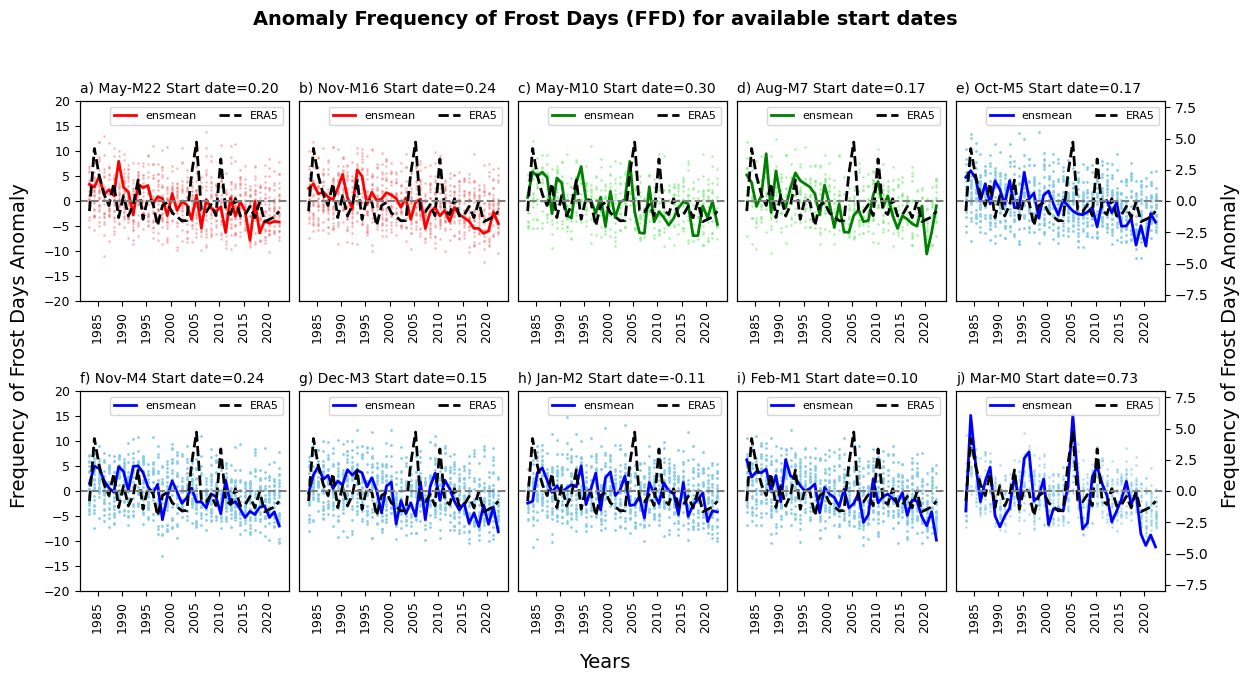

In [31]:
f,ax = plt.subplots(2,5,figsize=(14,7))
ax=ax.ravel()
f.subplots_adjust(top=0.85,bottom=0.15, hspace=0.45, wspace=0.05)
#f.tight_layout(h_pad=6,w_pad=4)

from matplotlib.ticker import MultipleLocator




years=np.arange(1983,2023)

for i in arange(0,24):
    ax[0].xaxis.set_tick_params(labelsize=9)
    ax[0].yaxis.set_tick_params(labelsize=9)
    ax[0].tick_params(axis='x', labelrotation=90)
    
    ax[0].set_ylim([-20,20])
    ax[0].yaxis.set_major_locator(MultipleLocator(5))

    ax[0].plot(dt,may_y2_index_1.fd[i,:],color='lightcoral',marker='o',lw=0,markersize=1,alpha=0.4)
    ax[1].xaxis.set_tick_params(labelsize=9)
    ax[1].yaxis.set_tick_params(labelsize=9)
    ax[1].tick_params(axis='x', labelrotation=90)
    ax[1].set_ylim([-20,20])
    ax[1].axes.get_yaxis().set_ticks([])
    ax[1].plot(dt,novy2_index_1.fd[i,:],color='lightcoral',marker='o',lw=0,markersize=1,alpha=0.4) 
ax1 = ax[0].twinx() 
ax1.set_ylim([-8,8])
ax1.axes.get_yaxis().set_ticks([])
ax1.plot(dt,anom_ensmean_index_may_y2,color='red',lw=2,linestyle='solid',label='ensmean') 
ax[0].plot(dt,may_y2_index_1.fd[0,:],color='lightcoral',marker='o',lw=0,label='members',markersize=1,alpha=0.4)
ax1.plot(dt,era5_index_1.fd,color='black',lw=2,linestyle='dashed',label='ERA5')
ax1.legend(fontsize=8,ncols=2,loc='upper right') 
#ax[0].set_title('Frequency of Frost days (nov start)',fontsize=12)
ax1.axhline(0,linestyle='dashed',color='gray')


ax2=ax[1].twinx() 
ax2.set_ylim([-8,8])
ax2.axes.get_yaxis().set_ticks([])
ax2.plot(dt,anom_ensmean_index_nov_y2,color='red',lw=2,linestyle='solid',label='ensmean') 
ax[1].plot(dt,novy2_index_1.fd[0,:],color='lightcoral',marker='o',lw=0,label='members',markersize=1,alpha=0.4)
ax2.plot(dt,era5_index_1.fd,color='black',lw=2,linestyle='dashed',label='ERA5')
ax2.legend(fontsize=8,ncols=2,loc='upper right') 
ax2.axhline(0,linestyle='dashed',color='gray')

for k in arange(0,14):  
    ax[2].xaxis.set_tick_params(labelsize=9)
    ax[2].tick_params(axis='x', labelrotation=90)
    ax[2].yaxis.set_tick_params(labelsize=9)

    ax[2].set_ylim([-20,20])
    ax[2].axes.get_yaxis().set_ticks([])
    ax[2].plot(dt,may_index_1.fd[k,0:40],color='lightgreen',marker='o',lw=0,markersize=1,alpha=0.6)
    ax[3].xaxis.set_tick_params(labelsize=9)
    ax[3].yaxis.set_tick_params(labelsize=9)
    ax[3].tick_params(axis='x', labelrotation=90)
    ax[3].set_ylim([-20,20])
    ax[3].axes.get_yaxis().set_ticks([])
    ax[3].plot(dt,aug_index_1.fd[k,:],color='lightgreen',marker='o',lw=0,markersize=1,alpha=0.6)

ax3=ax[2].twinx() 
ax3.set_ylim([-8,8])
ax3.axes.get_yaxis().set_ticks([])
ax3.plot(dt,anom_ensmean_index_may,color='green',lw=2,linestyle='solid',label='ensmean') 
ax[2].plot(dt,may_index_1.fd[0,0:40],color='lightgreen',marker='o',lw=0, label='members',markersize=1)
ax3.plot(dt,era5_index_1.fd,color='black',lw=2,linestyle='dashed',label='ERA5')
ax3.legend(fontsize=8,ncols=2,loc='upper right') 
ax3.axhline(0,linestyle='dashed',color='gray')

ax4=ax[3].twinx() 
ax4.set_ylim([-8,8])
ax4.axes.get_yaxis().set_ticks([])
ax4.plot(dt,anom_ensmean_index_aug,color='green',lw=2,linestyle='solid',label='ensmean') 
ax[3].plot(dt,aug_index_1.fd[0,:],color='lightgreen',marker='o',lw=0, label='members',markersize=1)
ax4.plot(dt,era5_index_1.fd,color='black',lw=2,linestyle='dashed',label='ERA5')
ax4.legend(fontsize=8,ncols=2,loc='upper right') 
ax4.axhline(0,linestyle='dashed',color='gray')

for i in arange(0,24):
#    ax.plot(x,memindex[i,:] ,color='black',label='frostdays',linestyle='solid')
    ax[4].xaxis.set_tick_params(labelsize=9)
    ax[4].yaxis.set_tick_params(labelsize=9)
    ax[4].tick_params(axis='x', labelrotation=90)
    ax[4].set_ylim([-20,20])
    ax[4].axes.get_yaxis().set_ticks([])
    ax[4].plot(dt, oct_index_1.fd[i,:],color='skyblue',marker='o',lw=0,markersize=1)
    ax[5].xaxis.set_tick_params(labelsize=9)
    ax[5].yaxis.set_tick_params(labelsize=9)
    ax[5].tick_params(axis='x', labelrotation=90)
    ax[5].set_ylim([-20,20])
    ax[5].yaxis.set_major_locator(MultipleLocator(5))

    ax[5].plot(dt,nov_index_1.fd[i,0:40],color='skyblue',marker='o',lw=0,markersize=1)
    ax[6].xaxis.set_tick_params(labelsize=9)
    ax[6].yaxis.set_tick_params(labelsize=9)
    ax[6].tick_params(axis='x', labelrotation=90)
    ax[6].set_ylim([-20,20])
    ax[6].axes.get_yaxis().set_ticks([])
    ax[6].plot(dt,dec_index_1.fd[i,:],color='skyblue',marker='o',lw=0,markersize=1)
    ax[7].xaxis.set_tick_params(labelsize=9)
    ax[7].yaxis.set_tick_params(labelsize=9)
    ax[7].tick_params(axis='x', labelrotation=90)
    ax[7].set_ylim([-20,20])
    ax[7].axes.get_yaxis().set_ticks([])
    ax[7].plot(dt,jan_index_1.fd[i,:],color='skyblue',marker='o',lw=0,markersize=1)
    ax[8].xaxis.set_tick_params(labelsize=9)
    ax[8].yaxis.set_tick_params(labelsize=9)
    ax[8].tick_params(axis='x', labelrotation=90)
    ax[8].set_ylim([-20,20])
    ax[8].axes.get_yaxis().set_ticks([])
    ax[8].plot(dt,feb_index_1.fd[i,0:40],color='skyblue',marker='o',lw=0,markersize=1)
    ax[9].xaxis.set_tick_params(labelsize=9)
    ax[9].yaxis.set_tick_params(labelsize=9)
    ax[9].tick_params(axis='x', labelrotation=90)
    ax[9].set_ylim([-20,20])
    ax[9].axes.get_yaxis().set_ticks([])
    ax[9].plot(dt,mar_index_1.fd[i,0:40],color='skyblue',marker='o',lw=0,markersize=1,alpha=0.5)
    
ax5=ax[4].twinx() 
ax5.set_ylim([-8,8])
ax5.plot(dt,anom_ensmean_index_oct,color='blue',lw=2,linestyle='solid',label='ensmean') 
ax[4].plot(dt,oct_index_1.fd[0,:],color='skyblue',marker='o',lw=0,label='members',markersize=1,alpha=0.4)
ax5.plot(dt,era5_index_1.fd,color='black',lw=2,linestyle='dashed',label='ERA5')
ax5.legend(fontsize=8,ncols=2,loc='upper right') 
#ax[0].set_title('Frequency of Frost days (nov start)',fontsize=12)
ax5.axhline(0,linestyle='dashed',color='gray')

ax6=ax[5].twinx() 
ax6.set_ylim([-8,8])
ax6.axes.get_yaxis().set_ticks([])
ax6.plot(dt,anom_ensmean_index_nov,color='blue',lw=2,linestyle='solid',label='ensmean') 
ax[5].plot(dt,nov_index_1.fd[0,0:40],color='skyblue',marker='o',lw=0,label='members',markersize=1,alpha=0.4)
ax6.plot(dt,era5_index_1.fd,color='black',lw=2,linestyle='dashed',label='ERA5')
ax6.legend(fontsize=8,ncols=2,loc='upper right') 
ax6.axhline(0,linestyle='dashed',color='gray')


ax7=ax[6].twinx() 
ax7.set_ylim([-8,8])
ax7.axes.get_yaxis().set_ticks([])
ax7.plot(dt,anom_ensmean_index_dec,color='blue',lw=2,linestyle='solid',label='ensmean') 
ax[6].plot(dt,dec_index_1.fd[0,:],color='skyblue',marker='o',lw=0,label='members',markersize=1,alpha=0.4)
ax7.plot(dt,era5_index_1.fd,color='black',lw=2,linestyle='dashed',label='ERA5')
ax7.legend(fontsize=8,ncols=2,loc='upper right') 
ax7.axhline(0,linestyle='dashed',color='gray')

#ax[1].legend(fontsize=10)
#ax[1].set_title('Frequency of Frost days (dec start)',fontsize=12)

ax8=ax[7].twinx() 
ax8.set_ylim([-8,8])
ax8.axes.get_yaxis().set_ticks([])

ax8.plot(dt,anom_ensmean_index_jan,color='blue',lw=2,linestyle='solid',label='ensmean') 
ax[7].plot(dt,jan_index_1.fd[0,:],color='skyblue',marker='o',lw=0,label='members',markersize=1,alpha=0.4)
ax8.plot(dt,era5_index_1.fd,color='black',lw=2,linestyle='dashed',label='ERA5')
ax8.legend(fontsize=8,ncols=2,loc='upper right') 
ax8.axhline(0,linestyle='dashed',color='gray')

#ax[2].legend(fontsize=10)
#ax[2].set_title('Frequency of Frost days (jan start)',fontsize=12)

ax9=ax[8].twinx() 
ax9.set_ylim([-8,8])
ax9.axes.get_yaxis().set_ticks([])
ax9.plot(dt,anom_ensmean_index_feb,color='blue',lw=2,linestyle='solid',label='ensmean') 
ax[8].plot(dt,feb_index_1.fd[0,0:40],color='skyblue',marker='o',lw=0,label='members',markersize=1,alpha=0.4)
ax9.plot(dt,era5_index_1.fd,color='black',lw=2,linestyle='dashed',label='ERA5')
ax9.legend(fontsize=8,ncols=2,loc='upper right')
ax9.axhline(0,linestyle='dashed',color='gray')


ax10=ax[9].twinx()
ax10.set_ylim([-8,8])
#ax9.axes.get_yaxis().set_ticks([])
ax10.plot(dt,anom_ensmean_index_mar,color='blue',lw=2,linestyle='solid',label='ensmean') 
ax[9].plot(dt,mar_index_1.fd[0,0:40],color='skyblue',marker='o',lw=0,label='members',markersize=1,alpha=0.4)
ax10.plot(dt,era5_index_1.fd,color='black',lw=2,linestyle='dashed',label='ERA5')
#ax[9].bar(years,era5_index_1.fd,color='black',label='ERA5')
ax10.legend(fontsize=8,ncols=2,loc='upper right')
ax10.axhline(0,linestyle='dashed',color='gray')



#ax[0].xaxis.set_tick_params(labelsize=6)
#ax[0].yaxis.set_tick_params(labelsize=6)



f.suptitle('Anomaly Frequency of Frost Days (FFD) for available start dates',fontsize=14, weight='bold')
f.text(0.075,0.5, 'Frequency of Frost Days Anomaly', rotation='vertical',fontsize=14,va='center')
f.text(0.94,0.5, 'Frequency of Frost Days Anomaly', rotation='vertical',fontsize=14,va='center')
f.text(0.5,0.04, 'Years', fontsize=14,ha='center')

#f.setp(axa.xaxis.get_majorticklabels(), rotation=45)
#plt.bar(time[iod2 > 0], iod2[iod2 > 0.4], color='r',label='positive IOD')
#plt.bar(time[iod2 < 2.6], iod2[iod2 < 2.6], color='cornflowerblue')
#plt.bar(time[iod2 < -0.4], iod2[iod2 < -0.4], color='b',label='negative IOD')
#plt.legend(prop={'size': 9}, fontsize='medium',loc='upper left',ncol=2)


#ax[0].set_title('a) Prediction Skill (May-Y2 Start)=%.2f' %skillmay_y2.statistic,fontsize=5)
#ax[1].set_title('b) Prediction Skill (Nov-Y2 Start)=%.2f' %skillnov_y2.statistic,fontsize=5)
#ax[2].set_title('c) Prediction Skill (May-Y1 Start)=%.2f' %skillmay.statistic,fontsize=5)
#ax[3].set_title('d) Prediction Skill (Aug-Y1 Start)=%.2f' %skillaug.statistic,fontsize=5)
#ax[4].set_title('e) Prediction Skill (Oct-Y1 Start)=%.2f' %skilloct.statistic,fontsize=5)
#ax[5].set_title('f) Prediction Skill (Nov-Y1 Start)=%.2f' %skillnov.statistic,fontsize=5)
#ax[6].set_title('g) Prediction Skill (Dec-Y1 Start)=%.2f' %skilldec.statistic,fontsize=5)
#ax[7].set_title('h) Prediction Skill (Jan-Y0 Start)=%.2f' %skilljan.statistic,fontsize=5)
#ax[8].set_title('i) Prediction Skill (Feb-Y0 Start)=%.2f' %skillfeb.statistic,fontsize=5)
#ax[9].set_title('j) Prediction Skill (Mar-Y0 Start)=%.2f' %skillmar.statistic,fontsize=5)

#for offset x=-0.06

ax[0].set_title('a) May-M22 Start date=%.2f' %skillmay_y2.statistic,fontsize=10,loc='left')
ax[1].set_title('b) Nov-M16 Start date=%.2f' %skillnov_y2.statistic,fontsize=10,loc='left')
ax[2].set_title('c) May-M10 Start date=%.2f' %skillmay.statistic ,fontsize=10,loc='left')
ax[3].set_title('d) Aug-M7 Start date=%.2f' %skillaug.statistic ,fontsize=10,loc='left')
ax[4].set_title('e) Oct-M5 Start date=%.2f' %skilloct.statistic ,fontsize=10,loc='left')
ax[5].set_title('f) Nov-M4 Start date=%.2f' %skillnov.statistic ,fontsize=10,loc='left')
ax[6].set_title('g) Dec-M3 Start date=%.2f' %skilldec.statistic ,fontsize=10,loc='left')
ax[7].set_title('h) Jan-M2 Start date=%.2f' %skilljan.statistic ,fontsize=10,loc='left')
ax[8].set_title('i) Feb-M1 Start date=%.2f' %skillfeb.statistic ,fontsize=10,loc='left')
ax[9].set_title('j) Mar-M0 Start date=%.2f' %skillmar.statistic ,fontsize=10,loc='left')

#mean_freq
#ax.axhline(mean_freq,linestyle='dashed',color='black',label='mean')
#ax.axhline(-2.6,linestyle='dashed',color='blue') 
#ax.legend(fontsize=10)
#mean_freq
#ax[0].set_ylabel('Frequency of Frost days', fontsize=10)
#ax[0].set_xlabel('Years',fontsize=10)
#ax[0].set_title('Frequency of Frost days',fontsize=15)


#plt.savefig(dirfig+"revised_Fig3_anom_FFDS_all_leads.png",dpi=300,bbox_inches='tight')